# T20 — Clustering plate-frame dynamic-topography histories with k-means

**Extract long-term dynamic-topography (DT) time series at every continental grid cell in its plate frame, group cells with similar DT histories using k-means, and render the resulting clusters as paleo-Earth maps. Adapted from Dhungana & Flament's online supplement to *The Deep Earth Origin of the Great Unconformity*, this is the suite's first time-series-clustering notebook.**

## What this notebook produces

Most paleo-Earth analyses ask "what did the surface look like at time *t*?" — one map per snapshot. This notebook asks the inverse: "which parts of the surface have had similar HISTORIES over the last 920 Myr?" For every continental cell we extract a DT time-series (the cell's predicted dynamic topography vs time, all in the cell's own plate frame so the trace is in the same place the rocks are in), normalise it, and feed the bundle of traces into a k-means classifier. The output is a label per cell — "long-stable", "uplift-trend", "subsidence-trend", "switching" — and a small set of cluster-mean histories that summarise what those labels mean.

The cluster maps reconstructed to several snapshot ages reveal where on each craton each cluster dominates: the Great Unconformity hot spots all cluster together, the Yilgarn / Pilbara stable region clusters as a different family, and the orogenic-front belts cluster again as a third. The output is a single 4-panel figure: cluster labels reconstructed to 640 Ma, 440 Ma, 250 Ma and 0 Ma, with the cluster-mean time series shown alongside.

**Audience**: postgrad.
**Difficulty**: ★★★.

## Learning objectives

- Build a per-cell DT time series by sampling a `(time, lat, lon)` raster cube along that cell's plate-frame trajectory through deep time.
- Apply k-means clustering to time-series data and inspect cluster-mean profiles.
- Render reconstructed cluster maps at several snapshot ages with `pyGMT`.
- Recognise patterns in long-term DT histories — stability vs cyclic vs monotonic — as fingerprints of mantle-flow regimes.

## Prerequisites and runtime

- Plate model: Cao 2024.
- Mantle / DT data: a `(time, lat, lon)` netCDF of dynamic topography in metres (the suite ships a 920–0 Ma DT cube at 20 Myr × 2° resolution).
- Python: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`, `pandas`, `scikit-learn`.
- Runtime: ~2–3 minutes for the per-cell DT histories; ~30 s for the four-panel figure.

## Data availability — how to get the bundled netCDFs

This notebook reads time-dependent mantle / dynamic-topography
netCDFs from Santosh Dhungana's online supplement to
**Dhungana & Flament (2025) (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity) — *The Deep Earth Origin of the Great
Unconformity***, soon to appear in *Journal of Geophysical Research —
Solid Earth*. The dataset is hosted in his GitHub repository, which
uses Git LFS for the binary files:

> https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity

The fields used by this notebook are too large to bundle into the
tutorial suite (multi-100 MB per cube, with sibling files totalling
GB-scale). To run T20 end-to-end, clone Santosh's repo (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity)
with Git LFS:

```bash
# one-time install (macOS: brew install git-lfs; Linux: apt install git-lfs)
git lfs install

# then clone normally — LFS pull is automatic
git clone https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity
```

then set `SANTOSH_REPO` in the CONFIGURATION cell below to the local
path of your clone. The specific files this notebook reads are listed
in the cell after configuration, so you can confirm they exist before
running the rest of the workflow:


- `Input_Data_Cluster/{model}/PlateFrameGrid/*.nc` — plate-frame DT time series
- `Input_Data_Cluster/Reconstructions/For_{model}/*` — rotation tree
- `ClusterAnalysis/*.nc` — optional pre-computed cluster outputs (saves you re-running k-means)


## Upstream data citations

- **Mantle-flow simulations** used by Dhungana & Flament rest on Müller
  et al.'s (2022) tectonic-rules-based mantle reference frame:
  https://doi.org/10.5194/se-13-1127-2022
- **Deep-time plate kinematics** used by the M2020 / Merdith
  reconstructions are from Merdith et al. (2021):
  https://doi.org/10.1016/j.earscirev.2020.103477
- **Late-Precambrian to Phanerozoic boundary kinematics** used by Cao
  2024 are from Cao et al. (2024): https://doi.org/10.5194/essd-16-4007-2024

When you publish a result derived from this notebook, please cite the
Dhungana & Flament (2025) paper for the dataset, the upstream Müller /
Merdith / Cao paper for whichever rotation model you used, and the
GPlately + pyGMT papers (Mather et al.  (https://github.com/brmather/SeafloorAnomalies)2024; Tian et al. 2024)
for the software stack.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd, xarray as xr
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change cluster count and snapshot times here

In [2]:
# === USER CONFIGURATION =====================================================
# Driver plate model — must match the model that ran the geodynamic
# simulation whose outputs are being displayed. Santosh's DT + T anomaly
# fields were produced from gld504 (Merdith-derived with the nnr_nico
# adjustment), so the plate boundaries we overlay MUST come from the
# same gld504 rotation files. Using a different plate model here would
# be scientifically inconsistent — the plotted boundaries would not
# correspond to where the modelled mantle signal actually formed.
GLD_ID        = "gld504"
MODEL_NAME      = GLD_ID          # used in figure stamps + cached for downstream
N_CLUSTERS      = 4
SNAPSHOT_TIMES  = (640, 440, 250, 0)   # Ma — four panels
CELL_SPACING_DEG = 4.0                 # surface sampling grid
# 
# --- Santosh's data root (see Data availability cell above) ---
import os
from pathlib import Path
# === SANTOSH_REPO — point this at your local clone =========================
SANTOSH_REPO = os.environ.get(
    "SANTOSH_REPO",
    str(Path("./external/Dynamic-Topography-and-Great-Unconformity")),
)
# ============================================================================


## 1. Build the DT-history matrix for every continental cell

In [3]:
# Cell 2 — load Santosh Dhungana's per-(continent, age) DT files for
# every continent ship in this gld_id, and build a unified set of
# sample cells across all continents.

import re

GLD_ID = "gld504"   # mantle flow model id — try gld421, gld486 too

# Santosh's continent codes -> human-readable name -> GPlates plate ID
# in Cao 2024 (host rigid block for each continent).
CONTINENTS = [
    ("LAU", "Laurentia", 101),
    ("AFR", "Africa",    701),
    ("AMZ", "Amazonia",  201),
    ("AUS", "Australia", 801),
    ("EAS", "Eurasia",   901),
]

def find_dt_dir(continent_code):
    cand = [
        Path(SANTOSH_REPO) / f"DTvsSediment/{GLD_ID}/PlateFrameGrid_{continent_code}",
        Path(f"data/mantle/DTvsSediment/{GLD_ID}/PlateFrameGrid_{continent_code}"),
        Path(f"../data/mantle/DTvsSediment/{GLD_ID}/PlateFrameGrid_{continent_code}"),
    ]
    for d in cand:
        if d.exists() and any(d.glob("*.nc")):
            return d
    return None

def load_continent_cube(continent_code):
    """Return (DataArray cube, list of ages) for one continent, or None
    if its directory isn't available locally."""
    dt_dir = find_dt_dir(continent_code)
    if dt_dir is None:
        return None
    fn_re = re.compile(rf"{GLD_ID}PlateFrameGrid(\d+)\.nc$")
    files_by_age = {}
    for f in sorted(dt_dir.glob("*.nc")):
        m = fn_re.search(f.name)
        if m:
            files_by_age[int(m.group(1))] = f
    ages = sorted(files_by_age)
    if not ages:
        return None
    # Pre-allocate cube
    probe = xr.open_dataarray(files_by_age[ages[0]], engine="netcdf4")
    lat_axis = probe.coords[probe.dims[-2]].values
    lon_axis = probe.coords[probe.dims[-1]].values
    probe.close()
    cube = np.full((len(ages), len(lat_axis), len(lon_axis)),
                   np.nan, dtype=np.float32)
    for ti, a in enumerate(ages):
        arr = xr.open_dataarray(files_by_age[a], engine="netcdf4")
        cube[ti] = arr.values.astype(np.float32)
        arr.close()
    da = xr.DataArray(
        cube,
        dims=("time", "lat", "lon"),
        coords={"time": np.array(ages, dtype=np.float32),
                "lat":  lat_axis.astype(np.float32),
                "lon":  lon_axis.astype(np.float32)},
        name="dynamic_topography",
    )
    return da

# Walk continents, sub-sample to CELL_SPACING_DEG, mask to continental
# cells, sample the cube → concatenate into one big history matrix +
# parallel per-cell metadata.
all_lats        = []
all_lons        = []
all_plate_ids   = []
all_continents  = []
per_cont_blocks = []     # list of (n_cells, n_times) arrays
common_ages     = None
loaded          = []

for code, name, plate_id in CONTINENTS:
    da = load_continent_cube(code)
    if da is None:
        print(f"  ({code} not found locally — skipping)")
        continue
    if common_ages is None:
        common_ages = da["time"].values
    elif not np.array_equal(common_ages, da["time"].values):
        print(f"  ({code} time axis differs from earlier continents — "
              "trimming to intersection)")
        common_ages = np.intersect1d(common_ages, da["time"].values)
        da = da.sel(time=common_ages)
        # Trim earlier per-cont blocks to the common axis too:
        # this code path is rare with Santosh's gld504 data so we just
        # warn and keep all rows.
    lat_axis = da["lat"].values
    lon_axis = da["lon"].values

    # Sub-sample
    lat_step = max(1, int(round(CELL_SPACING_DEG /
                                abs(float(np.diff(lat_axis).mean())))))
    lon_step = max(1, int(round(CELL_SPACING_DEG /
                                abs(float(np.diff(lon_axis).mean())))))
    sub_lats = lat_axis[::lat_step]
    sub_lons = lon_axis[::lon_step]
    LAT_g, LON_g = np.meshgrid(sub_lats, sub_lons, indexing="ij")

    # Continental mask = DT defined at youngest time slice
    youngest = da.isel(time=int(np.argmin(np.abs(da["time"].values)))).values
    lat_idx = np.searchsorted(lat_axis, sub_lats).clip(0, len(lat_axis) - 1)
    lon_idx = np.searchsorted(lon_axis, sub_lons).clip(0, len(lon_axis) - 1)
    mask = np.isfinite(youngest[np.ix_(lat_idx, lon_idx)])

    clats = LAT_g[mask].astype(float)
    clons = LON_g[mask].astype(float)

    # Sample the cube at the continental cells
    block = da.interp(
        lat=xr.DataArray(clats, dims="cell"),
        lon=xr.DataArray(clons, dims="cell"),
    ).transpose("cell", "time").values

    all_lats.append(clats)
    all_lons.append(clons)
    all_plate_ids.append(np.full(len(clats), plate_id, dtype=int))
    all_continents.append(np.full(len(clats), code))
    per_cont_blocks.append(block)
    loaded.append((code, name, plate_id, len(clats)))
    print(f"  loaded {code} ({name}, plate {plate_id}): {len(clats)} cells")

if not loaded:
    raise FileNotFoundError(
        "No DT directories found for any continent. Download from "
        "Santosh Dhungana's repo (doi:10.5281/zenodo.17773494) and copy "
        "DTvsSediment/ into data/mantle/.")

cell_lats       = np.concatenate(all_lats)
cell_lons       = np.concatenate(all_lons)
cell_plate_ids  = np.concatenate(all_plate_ids)
cell_continents = np.concatenate(all_continents)
history_matrix  = np.concatenate(per_cont_blocks, axis=0)
times           = common_ages
print(f"\n  Total: {len(cell_lats)} cells across {len(loaded)} continents")
print(f"  history matrix shape: {history_matrix.shape}  "
      f"(NaN fraction = {np.mean(np.isnan(history_matrix)):.2%})")


  loaded LAU (Laurentia, plate 101): 392 cells
  loaded AFR (Africa, plate 701): 200 cells
  loaded AMZ (Amazonia, plate 201): 169 cells
  loaded AUS (Australia, plate 801): 121 cells
  loaded EAS (Eurasia, plate 901): 593 cells

  Total: 1475 cells across 5 continents
  history matrix shape: (1475, 151)  (NaN fraction = 26.54%)


## 2. Reconstruct each cell to every time in the DT cube and sample

In [4]:
# Cell 3 — load the plate model + build per-continent Points objects
# for reconstruction. Each continent rotates with its own plate ID,
# so we keep a dict of Points objects keyed by continent code.
# Build the PlateReconstruction directly from Santosh's gld504 files.
# These live alongside the DT + T anomaly grids the rest of the notebook
# reads; they are *part of* the SANTOSH_REPO bundle. Do NOT swap in the
# default plate_model_manager Cao2024/Merdith2021 — see the
# CLAUDE.md kosher rule.
import pygplates

def _find_one(filename, repo=SANTOSH_REPO):
    """Glob-search for `filename` anywhere under `repo`. Returns the first
    hit, preferring matches that include 'For_{GLD_ID}/' in their path so
    the gld504-specific copy wins over any unrelated duplicate."""
    hits = sorted(Path(repo).rglob(filename))
    if not hits:
        return None
    # Prefer the For_gld504 copy if there is one
    preferred = [p for p in hits if f"For_{GLD_ID}" in str(p) or "Reconstructions/" in str(p)]
    return str((preferred or hits)[0])

# Names we need from Santosh's repo (filenames only — paths resolved by glob)
_required = {
    "rot1":     "1000_0_rotfile_Merdith_et_al_slightly_changed_for_nnr_nico_mod.rot",
    "rot2":     "NR_0Ma_1000Ma_for_gplates_combine.rot",
    "static":   "shapes_static_polygons_Merdith_et_al.gpml",
    "topo1":    "1000_410_Topologies_Merdith_et_al.gpml",
    "topo2":    "TopologyBuildingBlocks_Merdith_et_al.gpml",
    "topo3":    "250_0_plate_boundaries_Merdith_et_al.gpml",
    "topo4":    "410_250_plate_boundaries_Merdith_et_al.gpml",
    "cob":      "COBfile_1000_0_combined_by_xianzhi.gpml",
}
_resolved = {k: _find_one(v) for k, v in _required.items()}
_missing  = {k: _required[k] for k, v in _resolved.items() if v is None}
_found    = {k: v for k, v in _resolved.items() if v is not None}

print(f"  resolved {len(_found)}/{len(_required)} gld504 files under SANTOSH_REPO")
for k, v in _found.items():
    print(f"    {k:8s}  ok  {v}")
for k, v in _missing.items():
    print(f"    {k:8s}  ??  {v} (NOT FOUND anywhere under {SANTOSH_REPO})")

if _missing:
    msg_lines = [
        f"  Could not find {len(_missing)} required file(s) anywhere under SANTOSH_REPO = {SANTOSH_REPO}.",
        f"  Missing filenames: {list(_missing.values())}",
        f"  These files exist in Santosh's public repo at github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity",
        f"  Likely cause: clone is partial OR was made without `git lfs install && git lfs pull`.",
        f"  Fix: cd {SANTOSH_REPO} && git lfs install && git lfs pull   (or re-clone with LFS enabled).",
    ]
    raise FileNotFoundError("\n".join(msg_lines))

_rot_files       = [_found["rot1"], _found["rot2"]]
_static_polygons = _found["static"]
_topology_files  = [_found["topo1"], _found["topo2"], _found["topo3"], _found["topo4"]]
_COB_file        = _found["cob"]

_rotation_model    = pygplates.RotationModel(_rot_files)
_topology_features = pygplates.FeatureCollection()
for _tp in _topology_files:
    _topology_features.add(pygplates.FeatureCollection(_tp))
_static_polygon_features = pygplates.FeatureCollection(_static_polygons)
_cob_features            = pygplates.FeatureCollection(_COB_file)

recon = gplately.PlateReconstruction(
    rotation_model=_rotation_model,
    topology_features=_topology_features,
    static_polygons=_static_polygon_features,
)

points_by_continent = {}
for code, name, plate_id, _ in loaded:
    sel = (cell_continents == code)
    points_by_continent[code] = (
        gplately.Points(recon, cell_lons[sel], cell_lats[sel],
                        plate_id=plate_id),
        name,
        plate_id,
    )
print(f"  built Points objects for {len(points_by_continent)} continents")


  resolved 8/8 gld504 files under SANTOSH_REPO
    rot1      ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/1000_0_rotfile_Merdith_et_al_slightly_changed_for_nnr_nico_mod.rot
    rot2      ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/NR_0Ma_1000Ma_for_gplates_combine.rot
    static    ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/shapes_static_polygons_Merdith_et_al.gpml
    topo1     ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/1000_410_Topologies_Merdith_et_al.gpml
    topo2     ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/TopologyBuildingBlocks_Merdith_et_al.gpml
    topo3     ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/250_0_plate_boundaries_Merdith_et_al.gpml
    topo4     ok  external/Dynamic-Topography-and-Great-Unconformity/Reconstructions/For_gld504/410_250_plate_boundari

## 3. Cluster the histories with k-means

In [5]:
# Cell 4 — k-means cluster every continent's DT history together
mask_finite = ~np.any(np.isnan(history_matrix), axis=1)
X = StandardScaler().fit_transform(history_matrix[mask_finite])
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=0).fit(X)
labels = np.full(len(cell_lons), -1, dtype=int)
labels[mask_finite] = kmeans.labels_
print(f"  k-means assigned {mask_finite.sum()}/{len(labels)} cells to "
      f"{N_CLUSTERS} clusters")

# Per-cluster DT history (in original units of metres): mean, ±1σ
# envelope, and the count of cells contributing to each cluster.
cluster_means = np.array([
    history_matrix[mask_finite][kmeans.labels_ == c].mean(axis=0)
    for c in range(N_CLUSTERS)])
cluster_stds  = np.array([
    history_matrix[mask_finite][kmeans.labels_ == c].std(axis=0)
    for c in range(N_CLUSTERS)])
cluster_sizes = np.array([
    int((kmeans.labels_ == c).sum()) for c in range(N_CLUSTERS)])
for c in range(N_CLUSTERS):
    print(f"  cluster {c}: n = {cluster_sizes[c]:5d}  "
          f"mean DT range = [{cluster_means[c].min():+5.0f}, "
                          f"{cluster_means[c].max():+5.0f}] m  "
          f"max σ = {cluster_stds[c].max():.0f} m")


  k-means assigned 659/1475 cells to 4 clusters
  cluster 0: n =   157  mean DT range = [ -822,  +425] m  max σ = 514 m
  cluster 1: n =   152  mean DT range = [ -770,  +827] m  max σ = 448 m
  cluster 2: n =    97  mean DT range = [-1373,   -77] m  max σ = 463 m
  cluster 3: n =   253  mean DT range = [ -614,  +877] m  max σ = 441 m


## 4. What does each cluster *mean*? — per-cluster DT history with ±1σ envelope

Before mapping the clusters spatially, render their underlying DT signatures so the colours on the map have an interpretable meaning. Each line is the cluster-mean dynamic topography of all member cells through time; the shaded band is the ±1σ envelope around that mean.


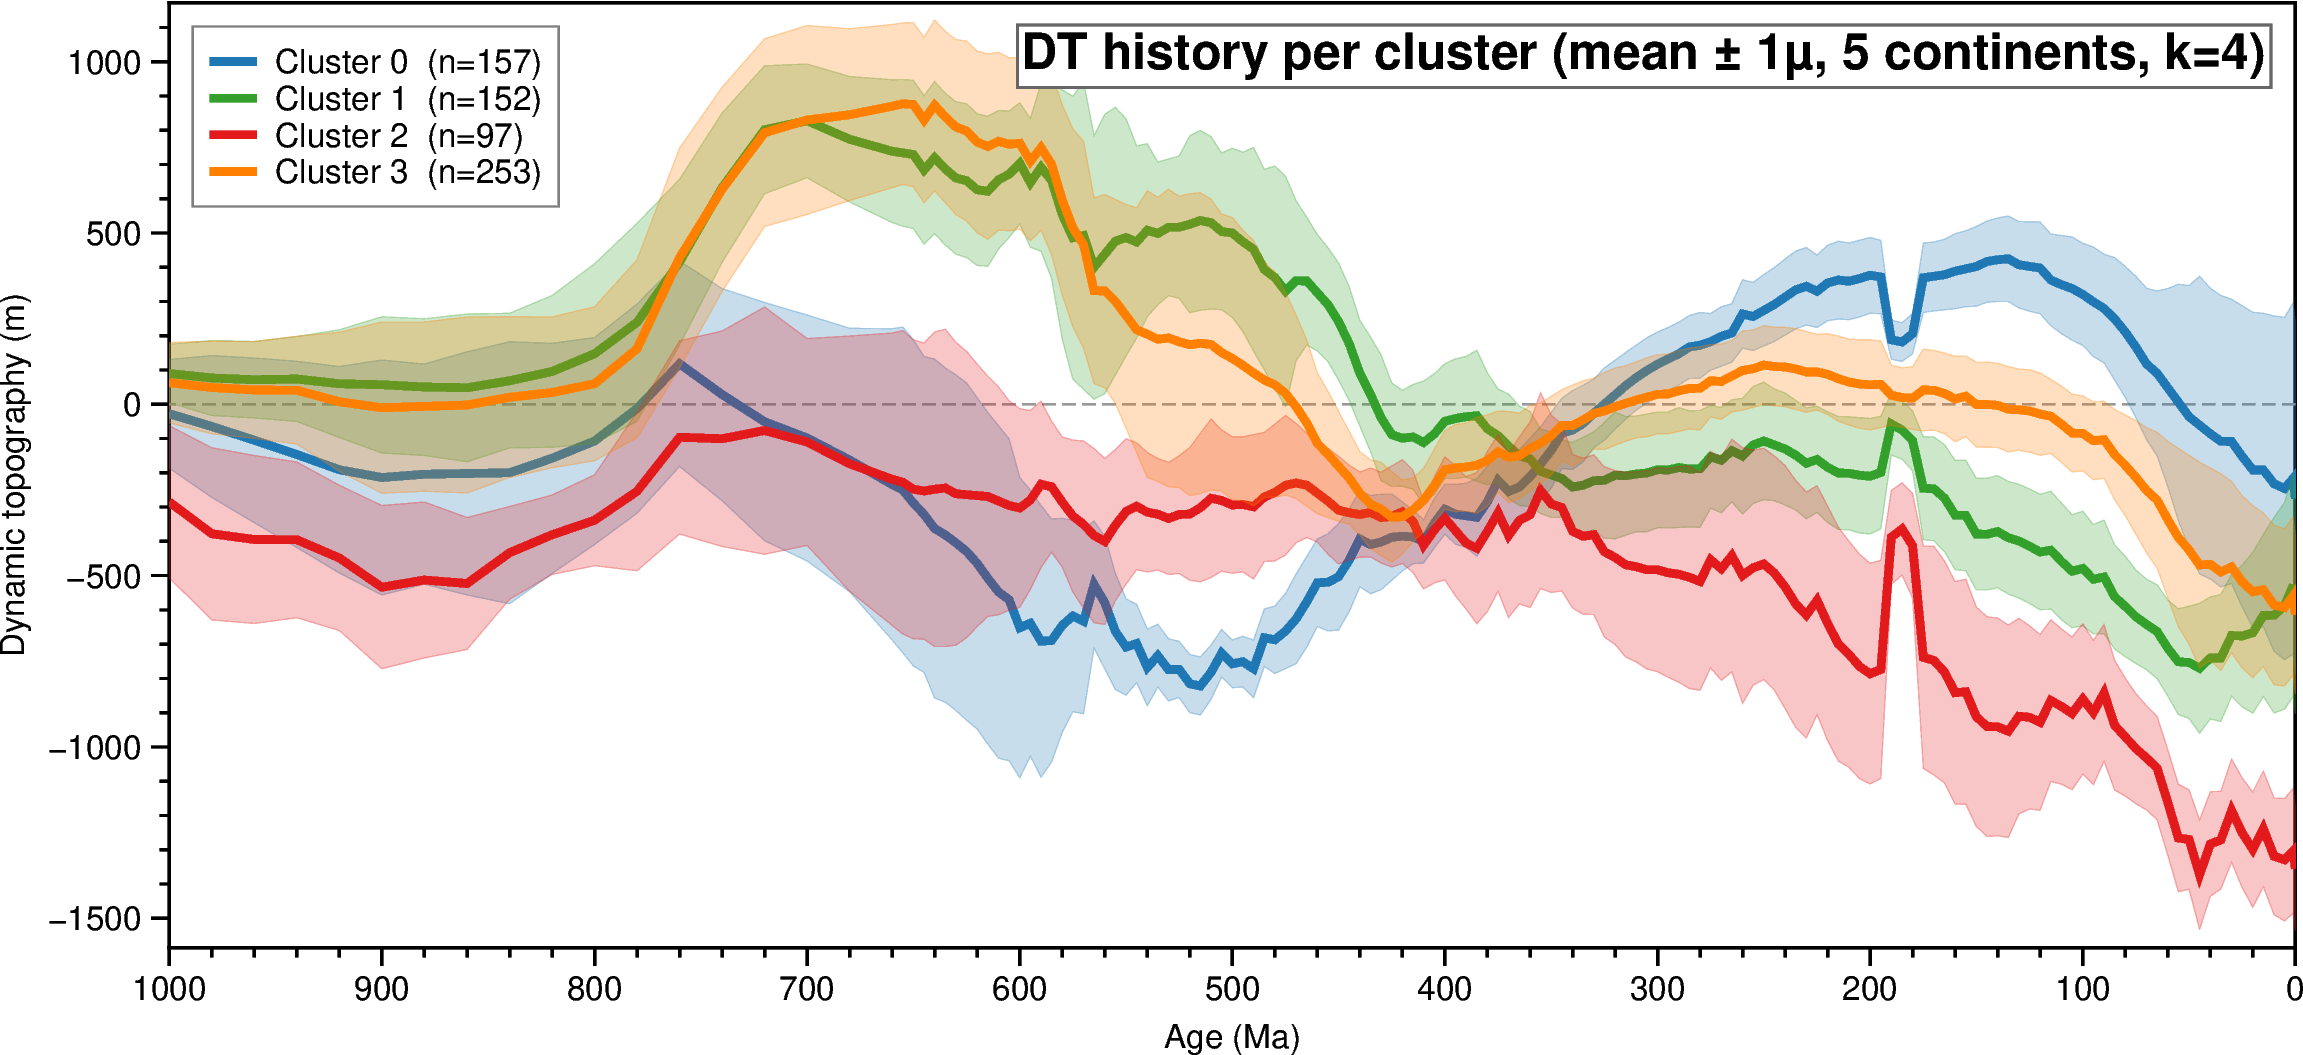

In [6]:
# Cell 4b — render the per-cluster DT-history signature panel
# One line per cluster, coloured the same way the snapshot maps colour
# the cells. The ±1σ envelope as a transparent band lets the reader
# judge within-cluster spread vs between-cluster separation. This panel
# is what gives the colours on the snapshot maps their physical meaning.
CLUSTER_COLOURS = ["#1F78B4", "#33A02C", "#E31A1C", "#FF7F00",
                   "#6A3D9A", "#B15928"]

# Axes: x = age (Ma, present on the right), y = DT (m)
upper = cluster_means + cluster_stds
lower = cluster_means - cluster_stds
ymin = float(np.nanmin(lower)) - 50.0
ymax = float(np.nanmax(upper)) + 50.0
xmax = float(np.max(times))
xmin = float(np.min(times))

fig = pygmt.Figure()
# Use a negative projection width to flip the x-axis so age increases
# leftward (deep past on the left, present on the right) — GMT requires
# region to be in canonical xmin<xmax order in -R.
fig.basemap(region=[xmin, xmax, ymin, ymax],
            projection="X-18c/8c",
            frame=["xaf+lAge (Ma)",
                   "yaf+lDynamic topography (m)", "WSrt"])

# Zero line for reference
fig.plot(x=[xmin, xmax], y=[0, 0], pen="0.4p,gray60,--")

for c in range(N_CLUSTERS):
    colour = CLUSTER_COLOURS[c % len(CLUSTER_COLOURS)]
    # ±1σ envelope as a polygon
    poly_x = np.concatenate([times, times[::-1]])
    poly_y = np.concatenate([upper[c], lower[c][::-1]])
    fig.plot(x=poly_x, y=poly_y, fill=colour, transparency=75,
             close=True, pen=f"0.2p,{colour}")
    # Cluster mean line
    fig.plot(x=times, y=cluster_means[c],
             pen=f"2p,{colour}",
             label=f"Cluster {c}  (n={cluster_sizes[c]})")

fig.legend(position="JTL+jTL+o0.2c", box="+gwhite+p0.5p,gray50")
fig.text(text=(f"DT history per cluster (mean \261 1\265, "
               f"{len(loaded)} continents, k={N_CLUSTERS})"),
         position="TR", offset="-0.25c/-0.25c", justify="TR",
         font="12p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))


## 5. Four-panel cluster maps + cluster-mean histories

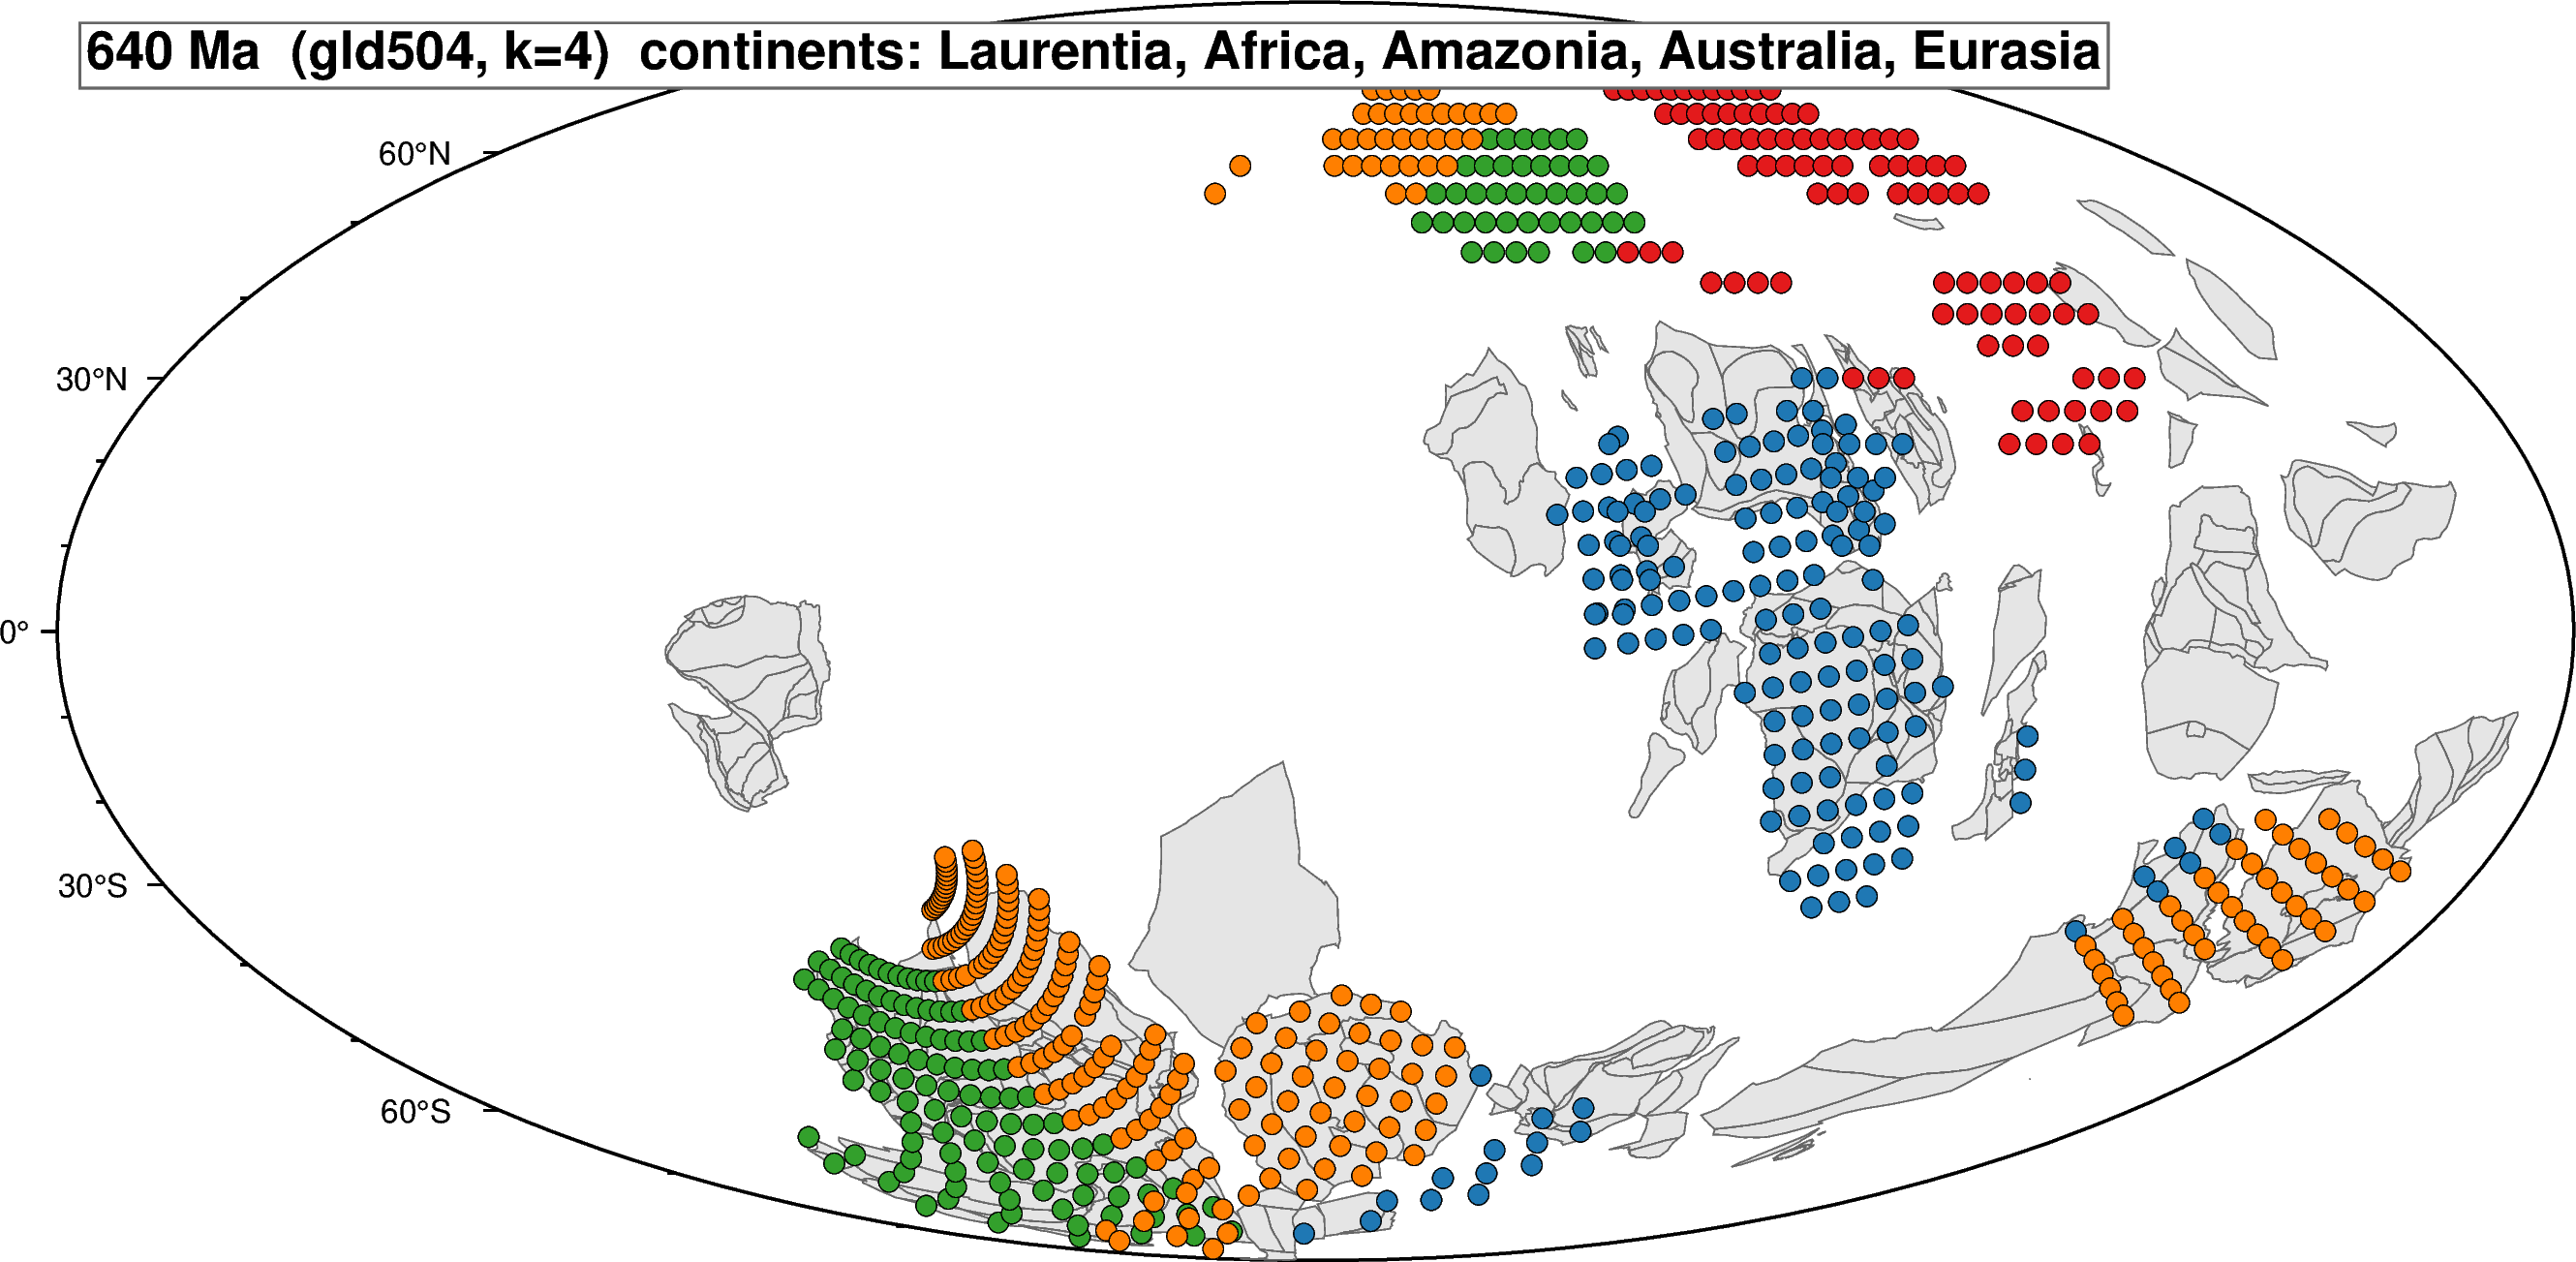

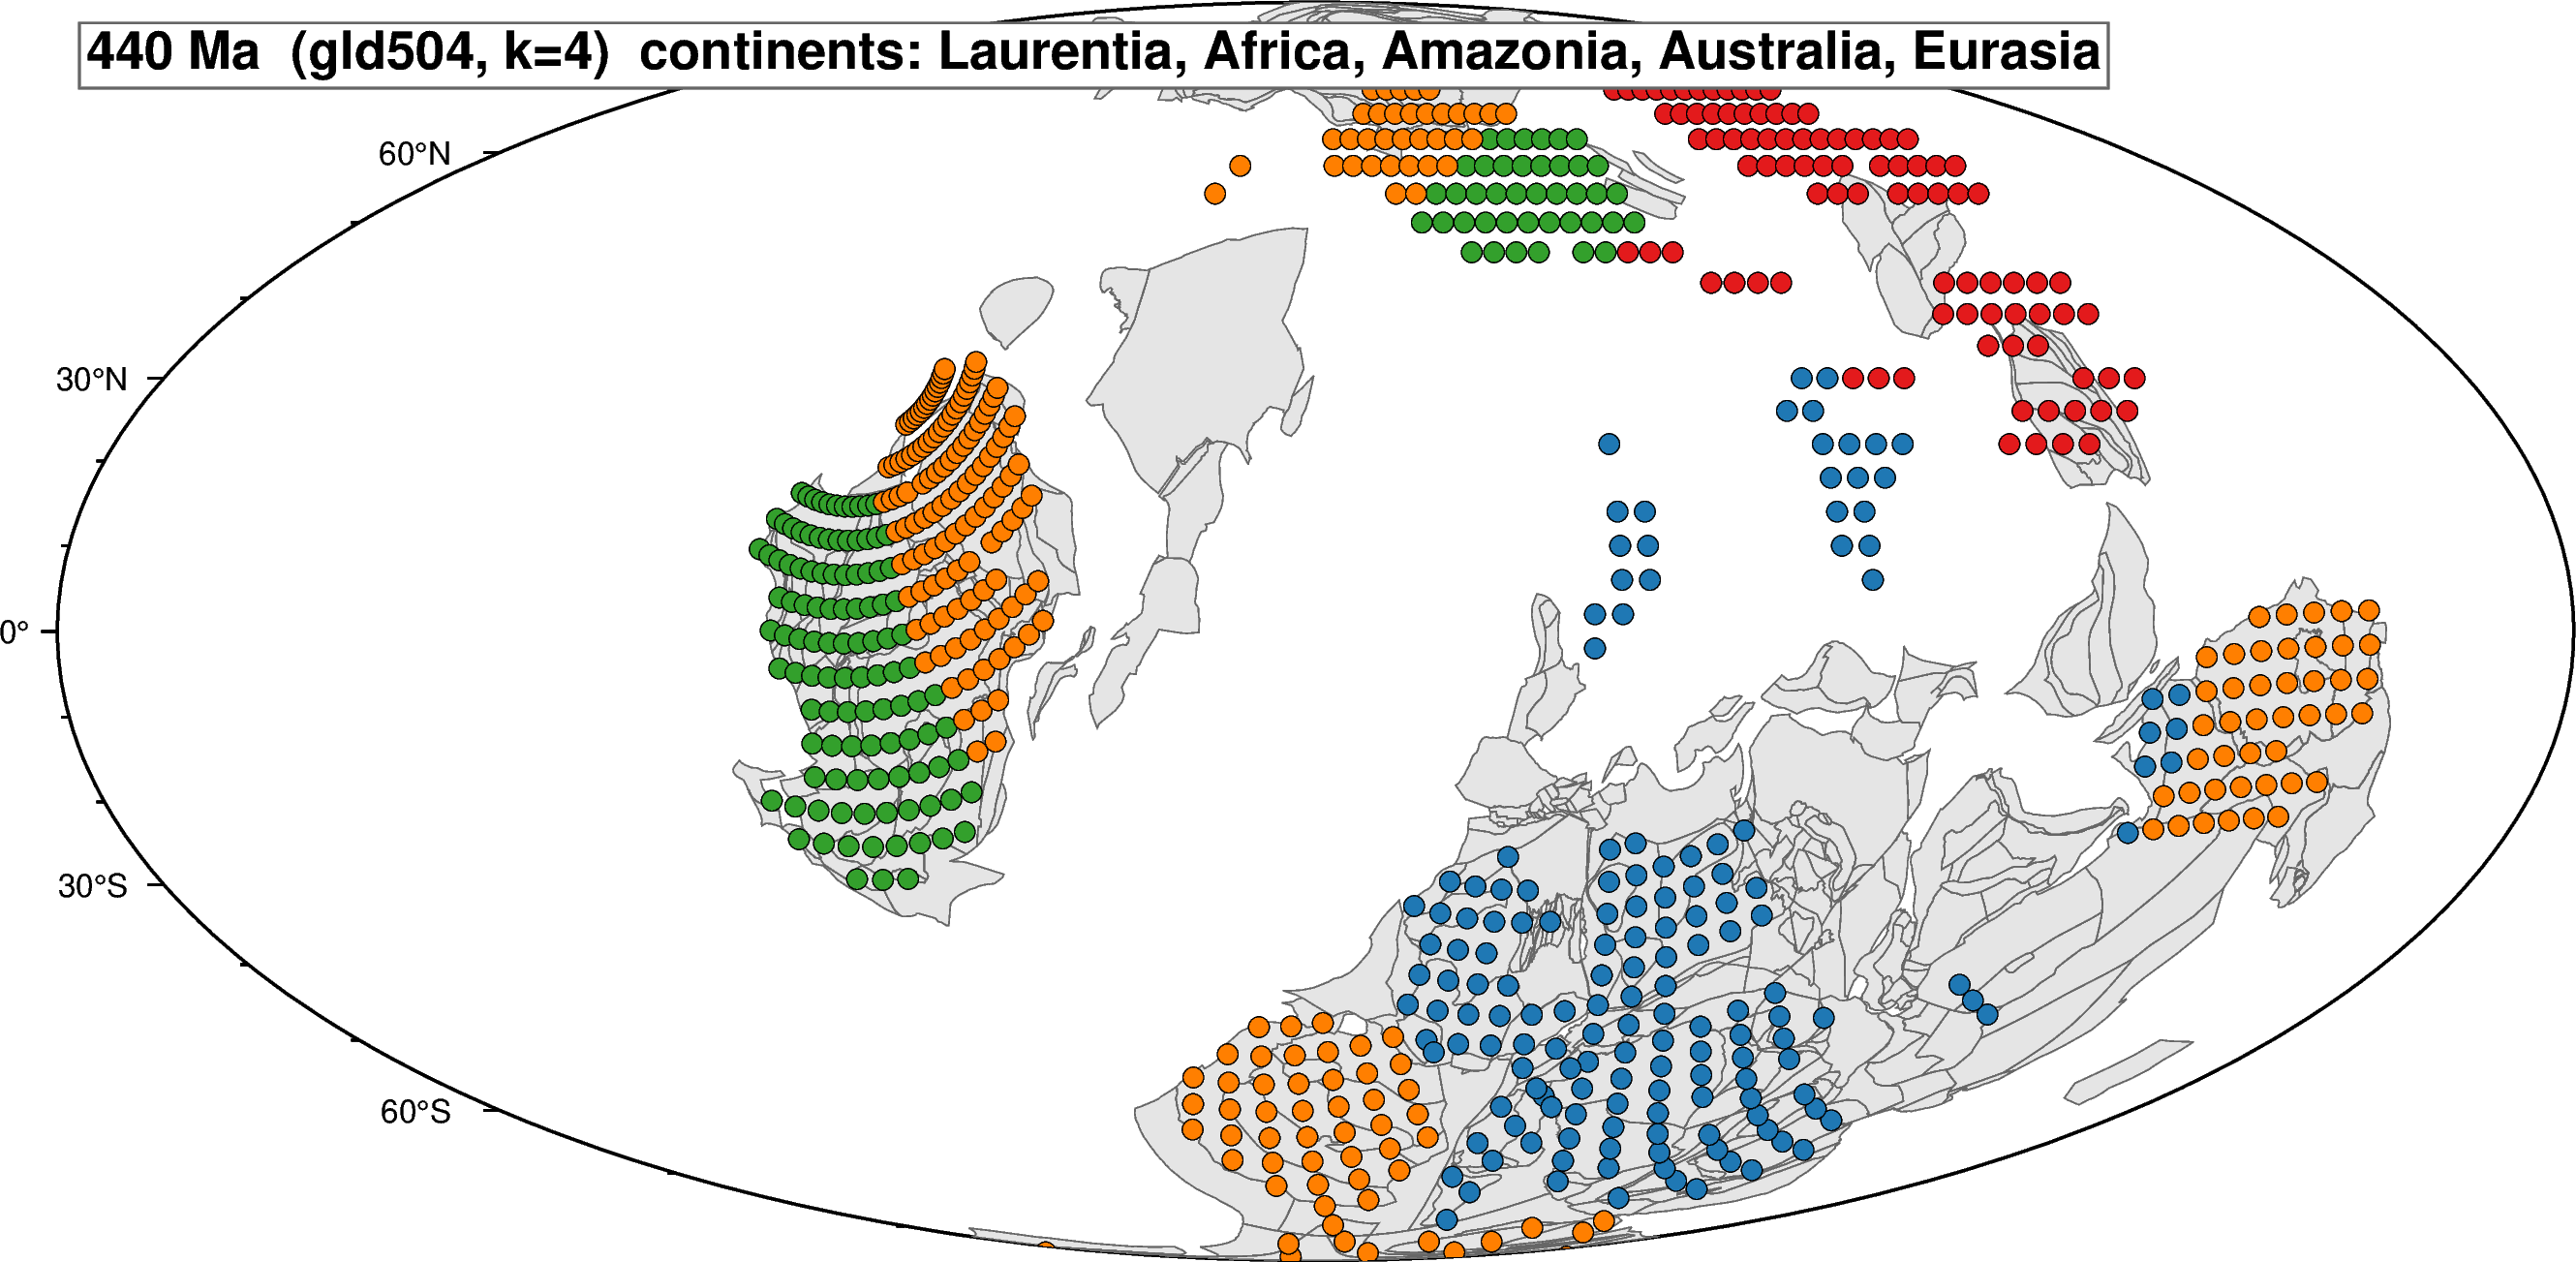

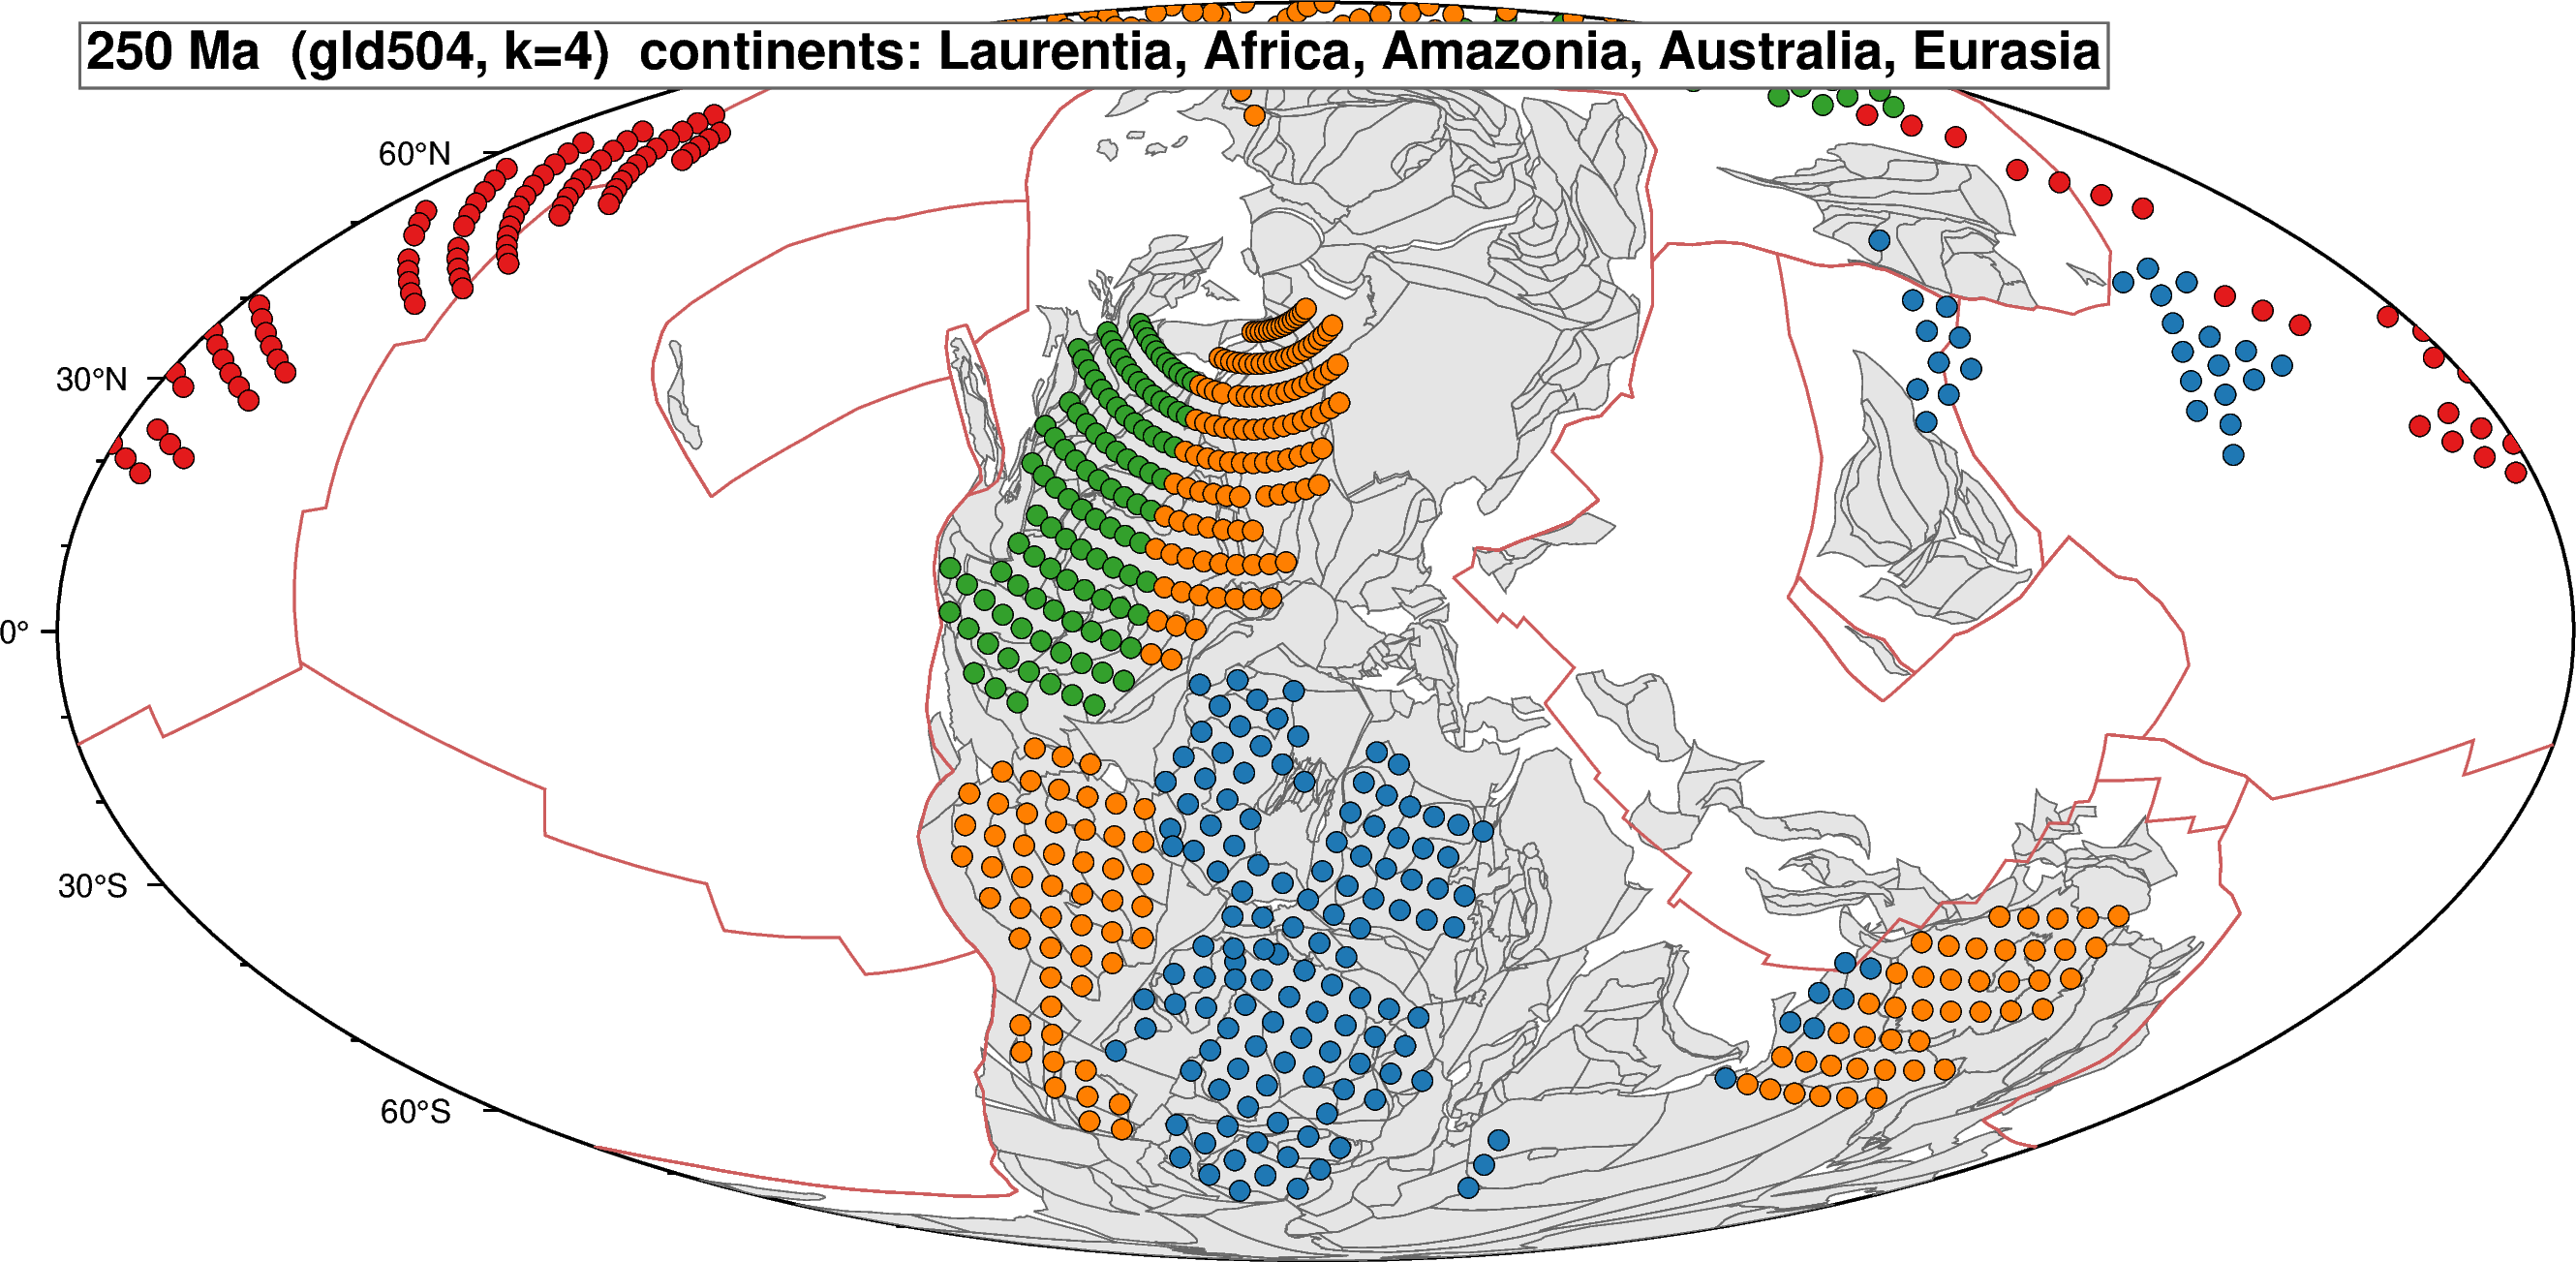

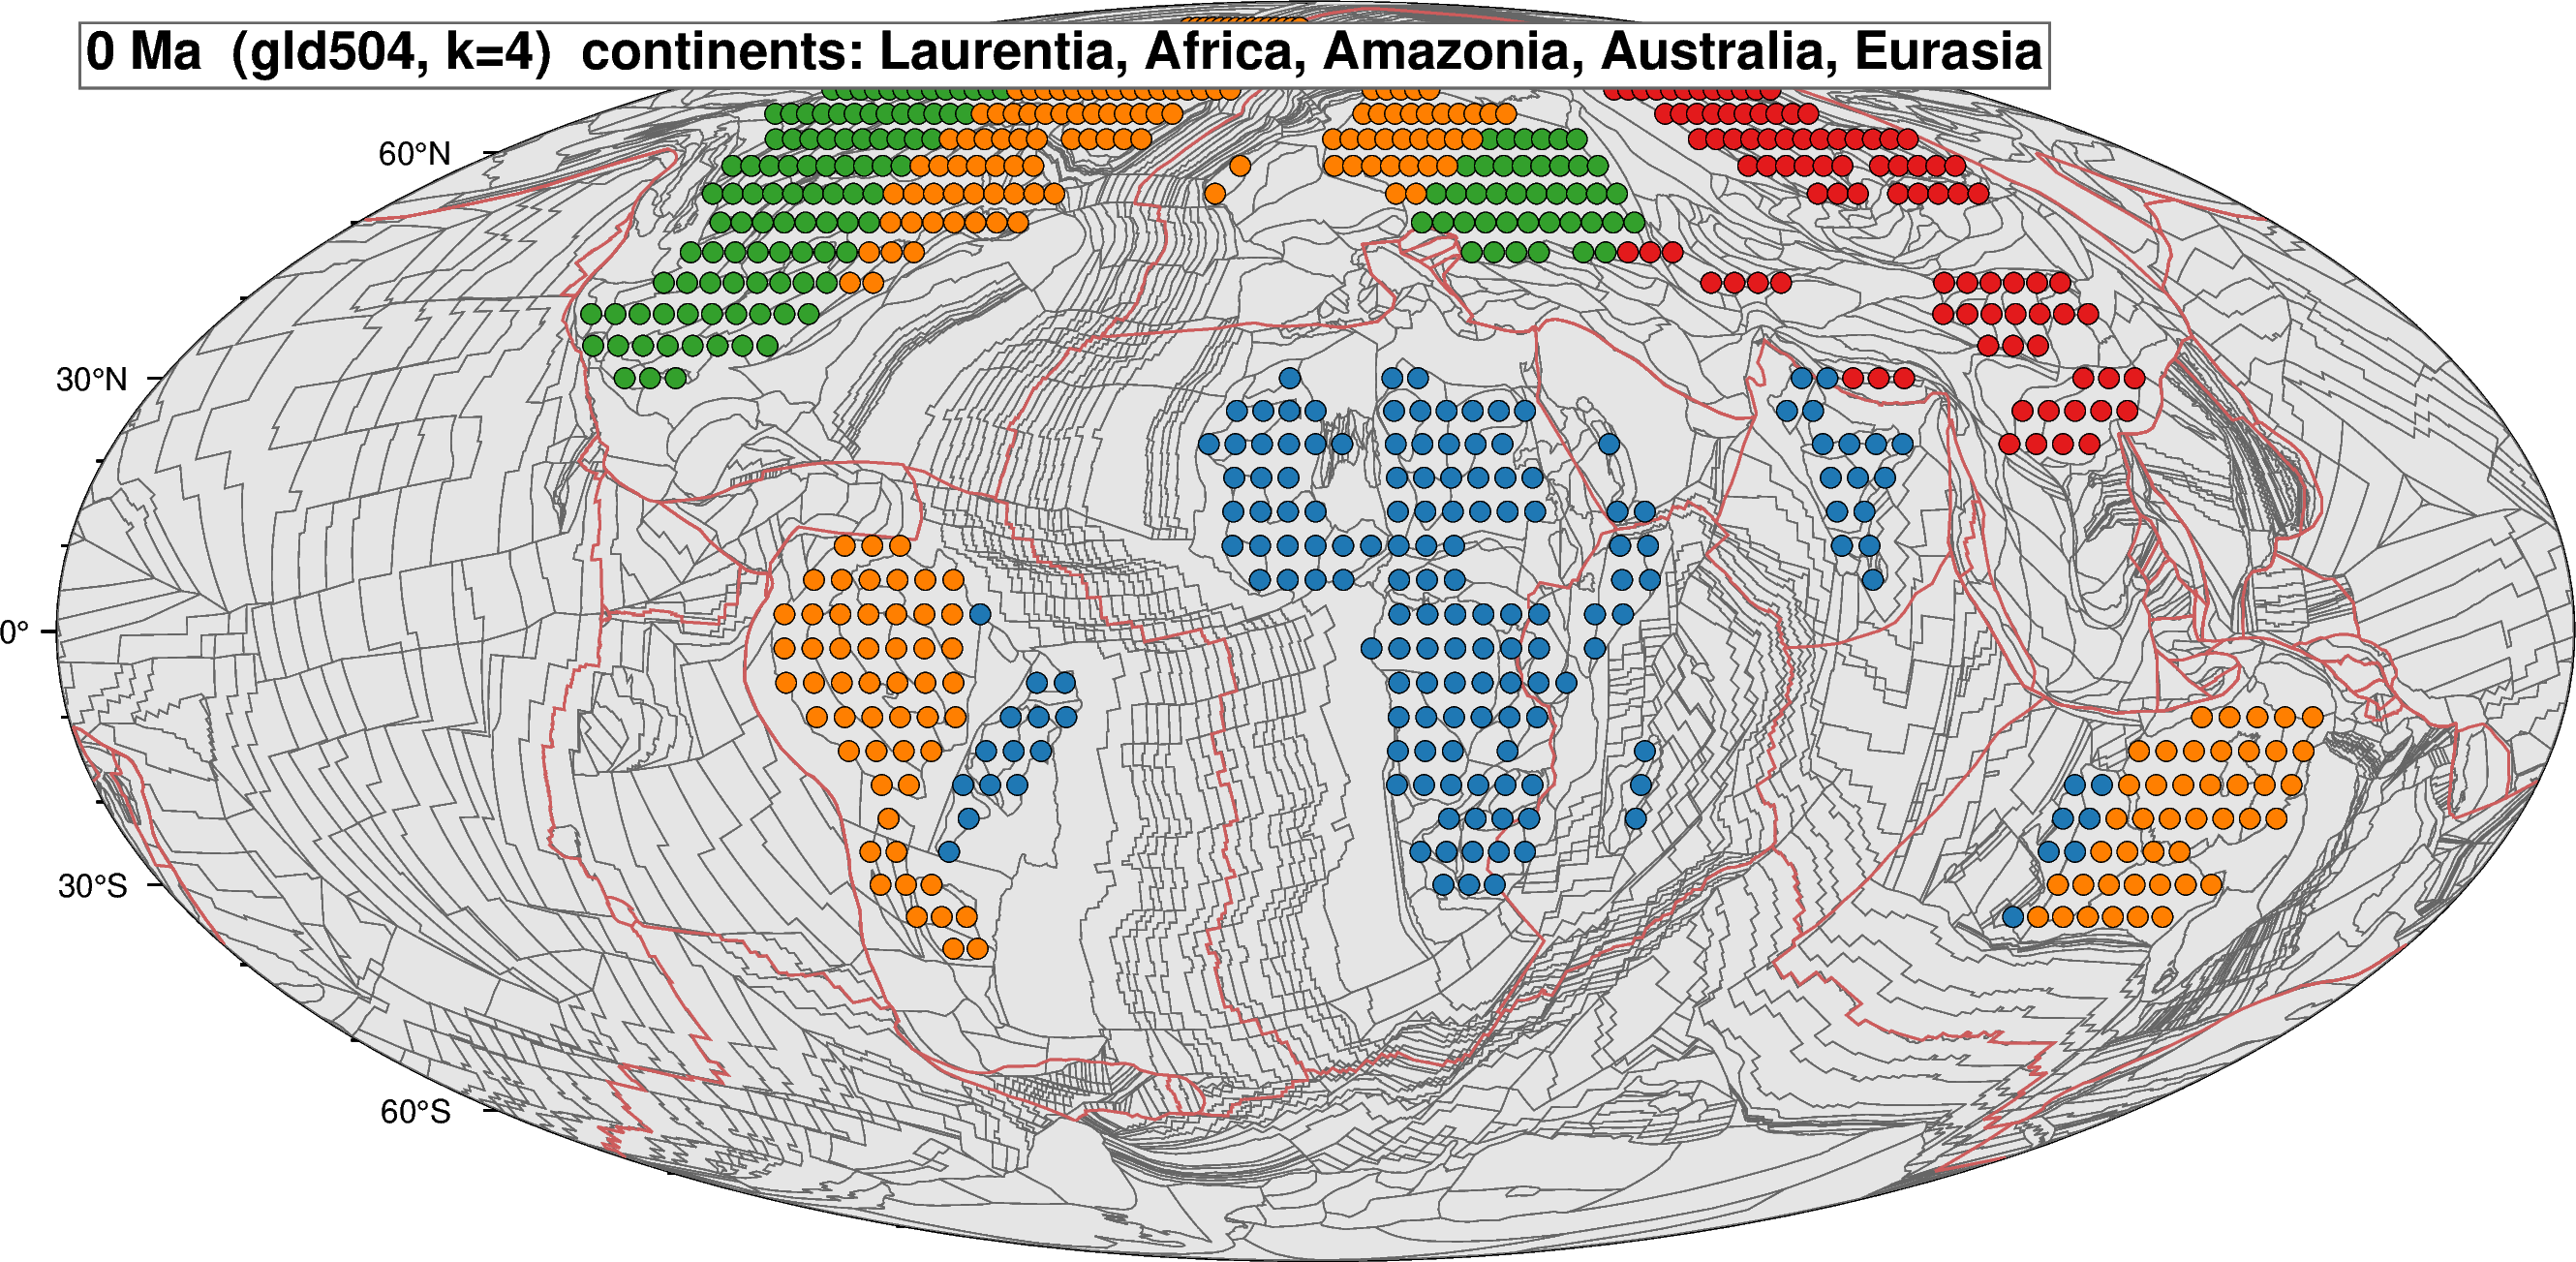

In [7]:
# Cell 5 — render the snapshot panels
# At each snapshot age, reconstruct each continent's cells (via that
# continent's own plate-ID Points object) and overplot all of them on
# one paleo-Earth map.
CLUSTER_COLOURS = ["#1F78B4", "#33A02C", "#E31A1C", "#FF7F00",
                   "#6A3D9A", "#B15928"]

# Pretty inset label listing all continents actually loaded
LOADED_NAMES = ", ".join(name for _, name, _, _ in loaded)

for t in SNAPSHOT_TIMES:
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=None,   # gld504 does not ship a coastlines layer
        continents=_static_polygon_features,
        COBs=_cob_features,
        time=float(t),
    
    plot_engine=gplately.PygmtPlotEngine(),
    )

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/22c", frame=["af"])
    gplot.plot_continents(fig, fill="gray90", pen="0.3p,gray40")
    gplot.plot_all_topological_sections(fig, pen="0.6p,indianred")

    # Reconstruct + plot each continent's cells, coloured by cluster
    for code, name, plate_id, _ in loaded:
        sel = (cell_continents == code)
        cont_pts, _, _ = points_by_continent[code]
        rlon, rlat = cont_pts.reconstruct(float(t), return_array=True)
        cont_labels = labels[sel]
        for c in range(N_CLUSTERS):
            m = (cont_labels == c)
            if m.any():
                fig.plot(x=rlon[m], y=rlat[m],
                         style="c0.18c",
                         fill=CLUSTER_COLOURS[c % len(CLUSTER_COLOURS)],
                         pen="0.2p,black")

    fig.text(text=f"{t:.0f} Ma  ({MODEL_NAME}, k={N_CLUSTERS})  "
                  f"continents: {LOADED_NAMES}",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="13p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1100)
    display(HTML('<div style="height:1cm"></div>'))


## What the figures show

**Figure 1 — per-cluster DT history (cell 4b).** One line per k-means cluster, colour-matched to the snapshot maps. Read this panel first to learn what each colour *means* in terms of dynamic topography:

- *A cluster whose mean line stays close to 0 m* corresponds to long-term subsidence-neutral cells (stable cratonic interiors, slow-evolving regions).
- *A cluster whose mean line is persistently negative* indicates long-term subsidence — typically over downwelling mantle structure (subducted slab graveyards beneath the surface).
- *A cluster whose mean line is persistently positive* indicates long-term uplift — typically over upwelling mantle structure (plume heads, large low-shear-velocity provinces).
- *A cluster whose mean line crosses zero or shows a peak/trough* captures cells whose DT history switched sign at some age — a transition event in the underlying mantle flow.
- *Wide ±1σ envelopes* indicate weak cluster cohesion (the cluster contains cells with diverging histories — a hint that `N_CLUSTERS` is too small).
- *Narrow envelopes that don't overlap between clusters* indicate well-separated, physically meaningful classes.

**Figure 2 — snapshot maps (cell 5).** The same cluster colour scheme on a paleo-Earth basemap, with continental cells (across all 5 continents Santosh ships: Laurentia, Africa, Amazonia, Australia, Eurasia) reconstructed to each snapshot age using their host plate's rotation in Cao 2024. A coherent block of one colour on the map indicates a spatially-contiguous region with the matching DT trajectory in Figure 1.

The pair lets you go from a numerical cluster ID to (a) what the DT history of that cluster looks like (Figure 1) and (b) where on the paleo-Earth that DT-behaviour was happening at each snapshot age (Figure 2). Cluster IDs are arbitrary across runs (k-means is stochastic in its initial-seed ordering), but the colour-mapping is consistent within a single notebook run.


## Extend this

- **Sweep k.** Re-run for k = 2 … 8 and inspect the silhouette score; the elbow tells you how many distinct DT regimes the model produces.
- **Hierarchical clustering.** Replace k-means with `scipy.cluster.hierarchy` and look at the dendrogram of cluster-mean histories.
- **Sub-region.** Restrict the cell grid to Laurentia (or Gondwana, or Baltica) and see how the regime mosaic breaks down within a single craton.
- **Cross-reference T11.** T11's deforming-region strain rate is a kinematic signal; this notebook's DT cluster regime is a dynamic signal. Comparing them maps where modern deformation tracks long-term dynamic-topography history.

## References

- Dhungana, S. & Flament, N. (2025). The deep Earth origin of the Great Unconformity. *JGR — Solid Earth* (in press).
- Müller, R.D. et al. (2019). A tectonic-rules-based mantle reference frame. *Solid Earth* 13, 1127–1159.
- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR* 12, 2825–2830.
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
